# Práctico 2: Manipulación de tablas y series de tiempo 

## Obtención de los datos

In [1]:
import pandas as pd
df=pd.read_csv("starbucks.csv")

### Primeros datos

In [2]:
df.head(10) #Impresión de los primeros 10 registros

,Store Number,Store Name,Address,City
0,10429-100710,Palmdale & Hwy 395,14136 US Hwy 395 Adelanto CA,Adelanto
1,635-352,Kanan & Thousand Oaks,5827 Kanan Road Agoura CA,Agoura
2,74510-27669,Vons-Agoura Hills #2001,5671 Kanan Rd. Agoura Hills CA,Agoura Hills
3,29839-255026,Target Anaheim T-0677,8148 E SANTA ANA CANYON ROAD AHAHEIM CA,AHAHEIM
4,23463-230284,Safeway - Alameda 3281,2600 5th Street Alameda CA,Alameda
5,6479-62999,Park & Central Alameda,1364 Park Street Alameda CA,Alameda
6,5535-728,Webster & Atlantic - Alameda,720 Atlantic Avenue Alameda CA,Alameda
7,74877-100291,Safeway - Alameda #2708,2227 South Shore Center Alameda CA,Alameda
8,11161-103516,Tilden & Blanding,"2671 Blanding Avene, D Alameda CA",Alameda
9,19859-196187,Target Alameda T-2829,2700 Fifth St Alameda CA,Alameda


## Operaciones con tablas

### a. Búsqueda de tienda por dirección utilizando .loc

In [3]:
df.loc[df['Address']== '1444 Shattuck Place Berkeley CA'] #Se busca en la columna Address el registro que contenga la dirección

,Store Number,Store Name,Address,City
155,17877-164526,Safeway - Berkeley #691,1444 Shattuck Place Berkeley CA,Berkeley


### b. Filtrado de registros por ciudad (Berkeley)

In [4]:
df.loc[df['City']== 'Berkeley'] #Se busca en la columna City los registros que contengan a Berkeley como ciudad

,Store Number,Store Name,Address,City
153,5406-945,2224 Shattuck - Berkeley,2224 Shattuck Avenue Berkeley CA,Berkeley
154,570-512,Solano Ave,1799 Solano Avenue Berkeley CA,Berkeley
155,17877-164526,Safeway - Berkeley #691,1444 Shattuck Place Berkeley CA,Berkeley
156,19864-202264,Telegraph & Ashby,3001 Telegraph Avenue Berkeley CA,Berkeley
157,9217-9253,2128 Oxford St.,2128 Oxford Street Berkeley CA,Berkeley


### c. Obtención de coordenadas geográficas (latitud y longitud)


In [5]:
from geopy.geocoders import Nominatim #Convertir direcciones en coordenadas
geolocator = Nominatim(user_agent="kaggle_learn") #Crea el geolocalizador que hace la busqueda
direccionTienda= df['Address'][14] #Prueba con la fila 15
locationPrueba = geolocator.geocode(direccionTienda) #Toma la dirección y devuelve un objeto(dirección, latitud, longitud)
print(locationPrueba.address)
print((locationPrueba.latitude, locationPrueba.longitude))

1220, West Main Street, Alhambra, Los Angeles County, California, 91801, United States
(34.091476, -118.1361991)


### d. Geocodificación y manejo de errores

In [6]:
import time
erroresDireccion= []

limite = 100  # límite de consultas
contador = 0

#Obtener latitud y longitud, se usa geolocalizador anterior

def obtener_coordenadas(direccion):
    global contador
    
    if contador >= limite:  # límite para no gastar consultas
        return None, None
    
    try:
        location=geolocator.geocode(direccion) #Toma la dirección y devuelve un objeto(dirección, latitud, longitud)
        time.sleep(1)  # se aumenta el tiempo para evitar saturar el servicio
        contador += 1

        if location: #Si encuentra la dirección devuelve latitud y longitud
            return location.latitude, location.longitude
        else:
            erroresDireccion.append(direccion) # Ocurre error, se agrega a lista de errores de dirección
            return None, None 

    except Exception as e:
        erroresDireccion.append(direccion)  # por si ocurre algo inesperado
        contador += 1
        return None, None
    
        
df[['Latitude', 'Longitude']] = df['Address'].apply( lambda x: pd.Series(obtener_coordenadas(x))) #Para la columna address se crean dos nuevas columnas (Latitud y Longitud) y para cada fila se llama a la función

#Mostramos resultados
print(df.head())

print("\nDirecciones con error:")
print(erroresDireccion)
print(f"\nDe las {contador} filas leídas, tenían errores:", len(erroresDireccion))


   Store Number               Store Name  \
0  10429-100710       Palmdale & Hwy 395   
1       635-352    Kanan & Thousand Oaks   
2   74510-27669  Vons-Agoura Hills #2001   
3  29839-255026    Target Anaheim T-0677   
4  23463-230284   Safeway - Alameda 3281   

                                   Address          City   Latitude  \
0             14136 US Hwy 395 Adelanto CA      Adelanto  34.506998   
1                5827 Kanan Road Agoura CA        Agoura  34.155889   
2           5671 Kanan Rd. Agoura Hills CA  Agoura Hills  34.153550   
3  8148 E SANTA ANA CANYON ROAD AHAHEIM CA       AHAHEIM        NaN   
4               2600 5th Street Alameda CA       Alameda  37.785531   

    Longitude  
0 -117.399952  
1 -118.756569  
2 -118.759190  
3         NaN  
4 -122.280575  

Direcciones con error:
['8148 E SANTA ANA CANYON ROAD AHAHEIM CA', '2671 Blanding Avene, D Alameda CA', '2210-J South Shore Drive Alameda CA', '2400 W. Commonwealth Alhambra CA', '26932 La Paz Ave Aliso Viejo CA

### e. Corrección de direcciones con fallos de geocodificación

In [ ]:
import re
import time

corregidas = []
fallidas = []

#Eliminar duplicados
erroresDireccion = list(set(erroresDireccion))
print("Sin duplicados:", len(erroresDireccion))

# FUNCIÓN DE LIMPIEZA

def limpiar_direccion(direccion):
    d = direccion.lower()

    # Errores de tipeo identificados
    d = re.sub(r'ahaheim', 'anaheim', d)
    d = re.sub(r'avene\b', 'avenue', d)

    # Guiones con letra (2210-J → 2210)
    d = re.sub(r'(\d+)-[a-z]\b', r'\1', d)

    # Eliminar todo después de la segunda coma 
    partes_coma = d.split(',')
    if len(partes_coma) >= 3:
        d = ','.join(partes_coma[:2])
    elif len(partes_coma) == 2:
        segunda = partes_coma[1].strip()
        if not re.match(r'^\d', segunda) and len(segunda.split()) > 2:
            d = partes_coma[0]

    # Números de suite/apt después de coma al final (", 101" → "")
    d = re.sub(r',\s*\d+\s*$', '', d)
    # Números de suite/apt en medio (", 101,") → ","
    d = re.sub(r',\s*\d{1,4}\s*,', ',', d)

    # Abreviaturas de tipo de calle
    d = re.sub(r'\bhwy\.?\b',      'highway', d)
    d = re.sub(r'\brd\.?\b',       'road',    d)
    d = re.sub(r'\bave\.?\b',      'avenue',  d)
    d = re.sub(r'\bblvd\.?\b',     'boulevard', d)
    d = re.sub(r'\bst\.?\b',       'street',  d)
    d = re.sub(r'\bdr\.?\b',       'drive',   d)
    d = re.sub(r'\bln\.?\b',       'lane',    d)
    d = re.sub(r'\bct\.?\b',       'court',   d)
    d = re.sub(r'\bpkwy\.?\b',     'parkway', d)
    d = re.sub(r'\bfwy\.?\b',      'freeway', d)

    # Eliminar info secundaria (suite, unit, etc.)
    d = re.sub(r'\b(suite|ste|unit|bldg|building|space|apt|floor|fl)\s*#?\w*', '', d)
    d = re.sub(r'#\d+', '', d)

    # Eliminar nombre propio + tipo comercial (ej: "Rock Creek Plaza", "Five Cities Center")
    if re.match(r'^\d+', d):
        d = re.sub(r'\b\w+\s+(plaza|mall|marketplace|shopping\s*center|towne?\s*center)\b', '', d)

    # Remover tipos comerciales sueltos que quedaron
    d = re.sub(r'\b(mall|plaza|marketplace|shopping\s*center|towne\s*center|town\s*center|center|junction|napa\s*junction)\b', '', d)

    # Quitar letras sueltas (unidades tipo "D", "J", etc.)
    d = re.sub(r'\b[a-z]\b', '', d)

    # Quitar caracteres especiales y espacios extra
    d = re.sub(r'[^a-z0-9\s]', ' ', d)
    d = re.sub(r'\s+', ' ', d).strip()

    # Ciudades pequeñas que geopy no resuelve bien : agregar condado
    ciudades_dificiles = {
        'aliso viejo':      'aliso viejo orange county california',
        'american canyon':  'american canyon napa county california',
        'alpine':           'alpine san diego county california',
        'anderson':         'anderson shasta county california',
    }
    for ciudad, reemplazo in ciudades_dificiles.items():
        if ciudad in d:
            d = re.sub(ciudad + r'.*$', reemplazo, d)
            return d  # ya tiene estado completo

    # Asegurar que termine con estado
    if not d.endswith(' ca') and ' ca ' not in d and 'california' not in d:
        d += ' ca'

    return d



# FUNCIÓN DE GEOCODIFICACIÓN CON FALLBACK

def geocodificar_con_fallback(geolocator, direccion_limpia):
    """
    Intenta geocodificar con versiones progresivamente más simples.
    Devuelve (location, intento_usado) o (None, direccion_limpia).
    """
    intentos = [direccion_limpia]

    partes = direccion_limpia.split()

    # Intento 2: número + 2 palabras de calle + últimas 2 (ciudad + estado)
    if len(partes) >= 5:
        simplificada = ' '.join(partes[:3] + partes[-2:])
        intentos.append(simplificada)

    # Intento 3: sin número de calle (solo calle + ciudad + estado)
    sin_numero = re.sub(r'^\d+\s+', '', direccion_limpia)
    if sin_numero != direccion_limpia:
        intentos.append(sin_numero)

    for intento in intentos:
        try:
            location = geolocator.geocode(intento)
            time.sleep(1)
            if location:
                return location, intento
        except Exception:
            time.sleep(1)

    return None, direccion_limpia



# LOOP PRINCIPAL

print("\n Reintentando direcciones con limpieza...\n")

for direccion in erroresDireccion:

    direccion_limpia = limpiar_direccion(direccion)
    location, intento_usado = geocodificar_con_fallback(geolocator, direccion_limpia)

    if location:
        corregidas.append({
            "original":   direccion,
            "modificada": intento_usado,
            "lat":        location.latitude,
            "lon":        location.longitude
        })
    else:
        fallidas.append({
            "original":   direccion,
            "modificada": direccion_limpia
        })



# RESULTADOS

print("RESULTADOS FINALES ")


print("\n Corregidas:")
for c in corregidas:
    print(c)

print("\n RESUMEN:")
print("Corregidas:", len(corregidas))

print("Fallidas:",  len(fallidas))


Sin duplicados: 36

 Reintentando direcciones con limpieza...

RESULTADOS FINALES 
Total en erroresDireccion: 36

Primeras 5:
2219 W. Ball Road, Anaheim Towne Center Anaheim CA
1211 East Grand Avenue, Suite 101, Five Cities Center Arroyo Grande CA
1640 Bell Lane, Five Corner Crossings Atwater CA
500 N. Brookhurst Street, Brookhurst Shopping Center Anaheim CA
4448 Lone Tree Way, Bluerock Center Antioch CA

 Fallidas:

 RESUMEN:
Corregidas: 36
Fallidas: 0


### f. Limpieza de direcciones (eliminación de ciudad y estado)

In [9]:
def remover_ciudad(row):
    address = row['Address']
    ciudad = row['City']
    
    ciudad_escaped = re.escape(ciudad)
    
    # eliminar ciudad + CA (con o sin coma)
    address_limpio = re.sub(
        rf',?\s*{ciudad_escaped}\s*,?\s*CA\b',
        '',
        address,
        flags=re.IGNORECASE
    )
    
    # limpiar comas sobrantes en el medio y final
    address_limpio = re.sub(r',\s*,', ',', address_limpio)  # dobles comas
    address_limpio = re.sub(r'[,\s]+$', '', address_limpio).strip()
    
    return address_limpio

df['Address'] = df.apply(remover_ciudad, axis=1)

print(df['Address'].head(10))

0                14136 US Hwy 395
1                 5827 Kanan Road
2                  5671 Kanan Rd.
3    8148 E SANTA ANA CANYON ROAD
4                 2600 5th Street
5                1364 Park Street
6             720 Atlantic Avenue
7         2227 South Shore Center
8          2671 Blanding Avene, D
9                   2700 Fifth St
Name: Address, dtype: str


### h. Creación de índice basado en el nombre de la tienda

In [12]:
df_con_indice = df.set_index('Store Name')
print(df_con_indice.head())

                         Store Number                       Address  \
Store Name                                                            
Palmdale & Hwy 395       10429-100710              14136 US Hwy 395   
Kanan & Thousand Oaks         635-352               5827 Kanan Road   
Vons-Agoura Hills #2001   74510-27669                5671 Kanan Rd.   
Target Anaheim T-0677    29839-255026  8148 E SANTA ANA CANYON ROAD   
Safeway - Alameda 3281   23463-230284               2600 5th Street   

                                 City   Latitude   Longitude  
Store Name                                                    
Palmdale & Hwy 395           Adelanto  34.506998 -117.399952  
Kanan & Thousand Oaks          Agoura  34.155889 -118.756569  
Vons-Agoura Hills #2001  Agoura Hills  34.153550 -118.759190  
Target Anaheim T-0677         AHAHEIM        NaN         NaN  
Safeway - Alameda 3281        Alameda  37.785531 -122.280575  


### i. Agrupación de tiendas por ciudad

In [13]:
df_agrupado = df.groupby('City').head(5)
print(df_agrupado)

      Store Number                  Store Name                       Address  \
0     10429-100710          Palmdale & Hwy 395              14136 US Hwy 395   
1          635-352       Kanan & Thousand Oaks               5827 Kanan Road   
2      74510-27669     Vons-Agoura Hills #2001                5671 Kanan Rd.   
3     29839-255026       Target Anaheim T-0677  8148 E SANTA ANA CANYON ROAD   
4     23463-230284      Safeway - Alameda 3281               2600 5th Street   
...            ...                         ...                           ...   
2816  14071-108147  Hwy 20 & Tharp - Yuba City      1615 Colusa Hwy, Ste 100   
2817    9974-98559  Yucaipa & Hampton, Yucaipa        31364 Yucaipa Blvd., A   
2818  79654-108478        Vons - Yucaipa #1796            33644 YUCAIPA BLVD   
2819   6438-245084               Yucaipa & 6th      34050 Yucaipa Blvd., 200   
2820    6829-82142   Highway 62 & Warren Vista       57744  29 Palms Highway   

              City   Latitude   Longitu

##  Manejo de series de tiempo

### a. Carga de archivos CSV en dataframes

In [2]:
import pandas as pd

df_2023= pd.read_csv("inumet_temperatura-del-aire-2023.csv")
df_2024= pd.read_csv("inumet_temperatura-del-aire-2024.csv")

df_2023.head()
df_2024.head()

,fecha,estacion_idStr,TempAire
0,2024-01-01T00:00:00.000Z,CARRASCO,21.9
1,2024-01-01T00:00:00.000Z,aeropuertomelillag3,20.2
2,2024-01-01T01:00:00.000Z,CARRASCO,21.3
3,2024-01-01T01:00:00.000Z,aeropuertomelillag3,19.9
4,2024-01-01T02:00:00.000Z,CARRASCO,19.7


### b. Unificación de dataframes en una sola tabla

In [5]:
#Verificamos que las columnas coincidan
print(df_2023.columns)
print(df_2024.columns)

#Concatenación

df_concatenado = pd.concat([df_2023, df_2024], ignore_index=True)

#Verificación de concatenación

df_concatenado.head()
df_concatenado.info()

#Convertir temperatura a numérico y fecha a datetime

df_concatenado['fecha'] = pd.to_datetime(df_concatenado['fecha'])
df_concatenado['TempAire'] = pd.to_numeric(df_concatenado['TempAire'], errors='coerce')

df_concatenado = df_concatenado.sort_values('fecha').reset_index(drop=True)

print(df_concatenado['fecha'].min())
print(df_concatenado['fecha'].max())

df_concatenado.info()


Index(['fecha', 'estacion_idStr', 'TempAire'], dtype='str')
Index(['fecha', 'estacion_idStr', 'TempAire'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 21359 entries, 0 to 21358
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   fecha           21359 non-null  str   
 1   estacion_idStr  21359 non-null  str   
 2   TempAire        21310 non-null  object
dtypes: object(1), str(2)
memory usage: 500.7+ KB
2023-01-01 00:00:00+00:00
2024-03-20 23:00:00+00:00
<class 'pandas.DataFrame'>
RangeIndex: 21359 entries, 0 to 21358
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   fecha           21359 non-null  datetime64[us, UTC]
 1   estacion_idStr  21359 non-null  str                
 2   TempAire        21309 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 500.7 KB


### c. Graficar el comportamiento de la temperatura en función del tiempo.

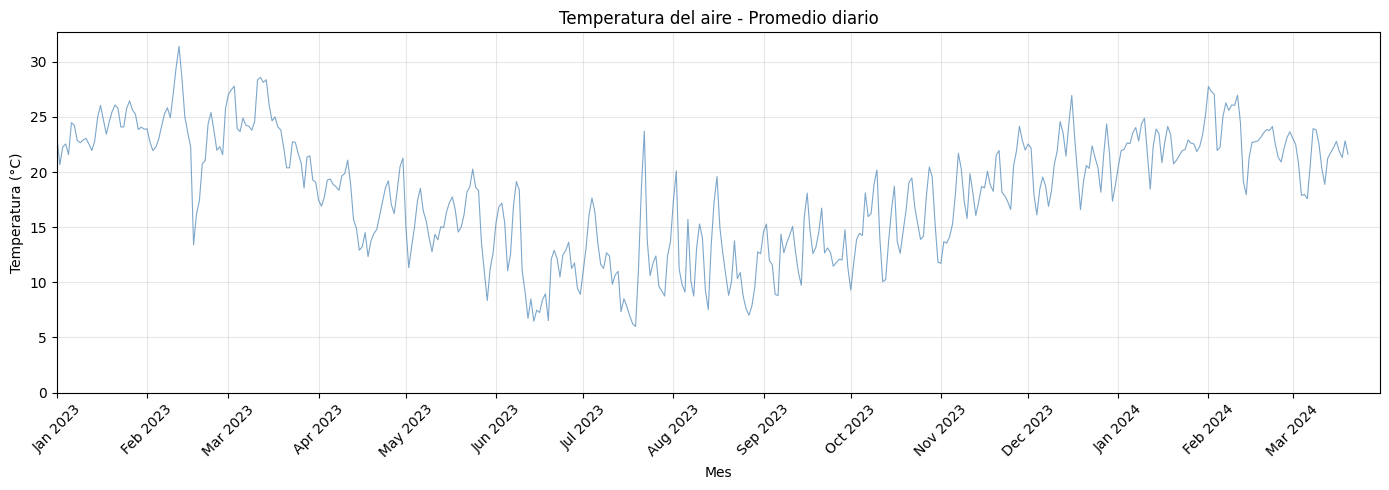

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_diario = df_concatenado.groupby('fecha')['TempAire'].mean().resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_diario.index, df_diario.values, color='steelblue', linewidth=0.8, alpha=0.7)

ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-03-31'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.set_title('Temperatura del aire - Promedio diario')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
ax.set_ylim(0, None)
plt.show()

### d. Crear un filtro para poder ver mejor las tendencias.

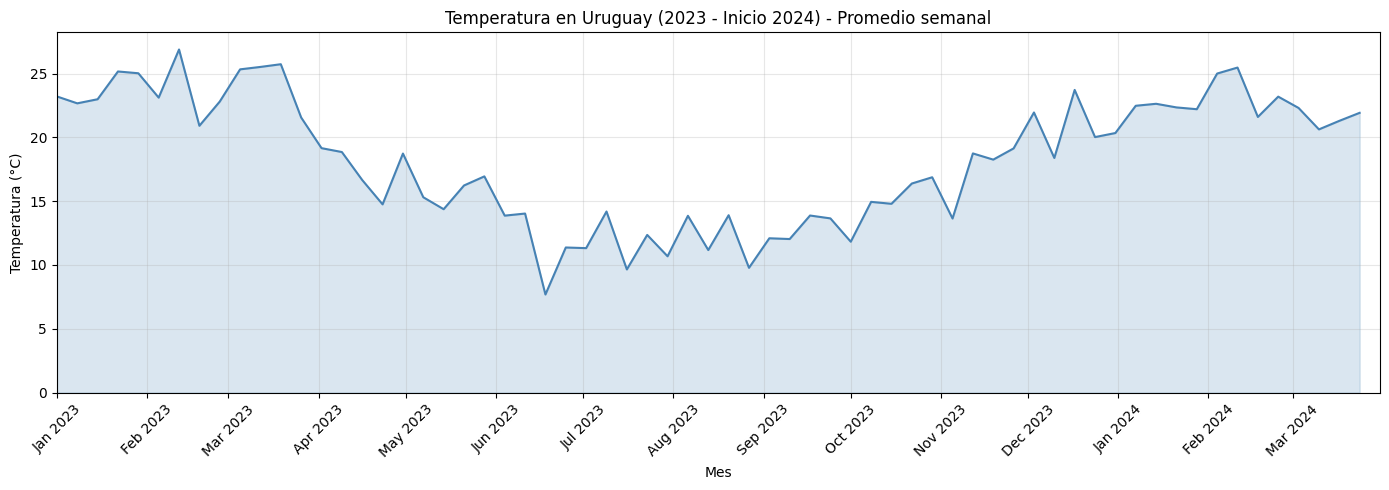

In [66]:

# Promedio semanal de todas las estaciones
df_semanal = df_concatenado.groupby('fecha')['TempAire'].mean().resample('W').mean()

# Graficar
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_semanal.index, df_semanal.values, color='steelblue', linewidth=1.5)
ax.fill_between(df_semanal.index, df_semanal.values, alpha=0.2, color='steelblue')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Temperatura en Uruguay (2023 - Inicio 2024) - Promedio semanal')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-03-31'))
plt.tight_layout()
plt.show()

### e. Graficar la temperatura para distintos períodos de tiempo.

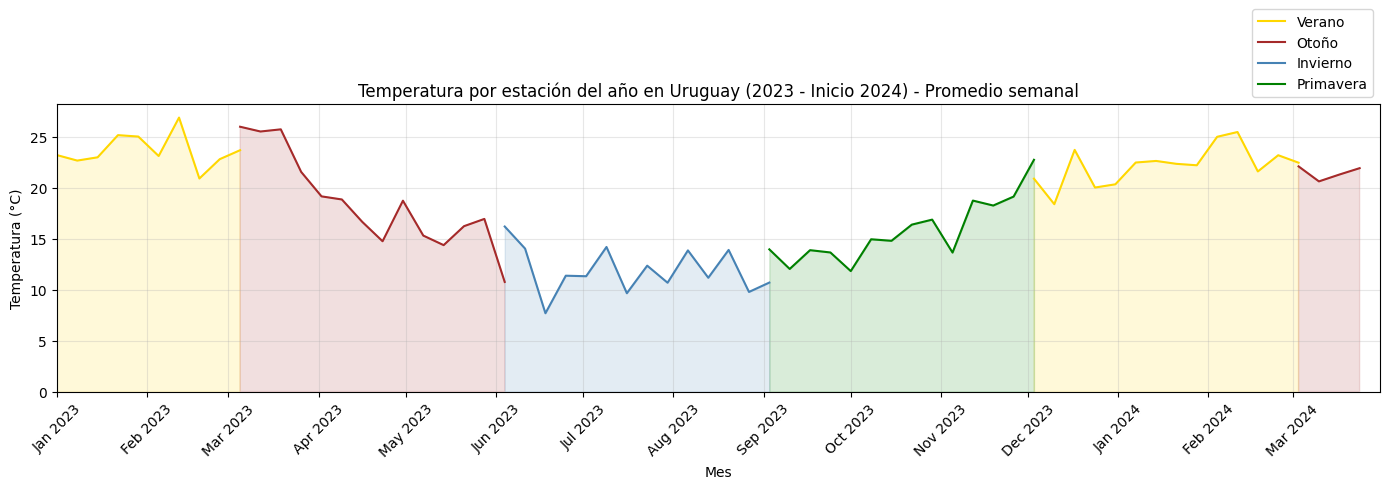

In [71]:
def estacion(fecha):
    mes = fecha.month
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    else:
        return 'Primavera'

df_concatenado['estacion'] = df_concatenado['fecha'].apply(estacion)

colores = {'Verano': 'gold', 'Otoño': 'brown', 'Invierno': 'steelblue', 'Primavera': 'green'}

fig, ax = plt.subplots(figsize=(14, 5))

for est in ['Verano', 'Otoño', 'Invierno', 'Primavera']:
    df_est = df_concatenado[df_concatenado['estacion'] == est]
    df_est_semanal = df_est.groupby('fecha')['TempAire'].mean().resample('W').mean()
    ax.plot(df_est_semanal.index, df_est_semanal.values, color=colores[est], linewidth=1.5, label=est)
    ax.fill_between(df_est_semanal.index, df_est_semanal.values, alpha=0.15, color=colores[est])

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-03-31'))
ax.set_title('Temperatura por estación del año en Uruguay (2023 - Inicio 2024) - Promedio semanal')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.legend(loc='lower right', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

### f. Generación de puntos intermedios entre observaciones

In [72]:
# Filtrar último año (2024)
df_2024 = df_concatenado[df_concatenado['fecha'].dt.year == 2024].copy()
df_2024 = df_2024.groupby('fecha')['TempAire'].mean()  # promedio de estaciones

# Reindexar cada 30 minutos 
nuevo_indice = pd.date_range(
    start=df_2024.index.min(),
    end=df_2024.index.max(),
    freq='30min'
)

df_reindexado = df_2024.reindex(nuevo_indice)

print("Antes de interpolar:")
print(df_reindexado.head(10))



Antes de interpolar:
2024-01-01 00:00:00+00:00    21.05
2024-01-01 00:30:00+00:00      NaN
2024-01-01 01:00:00+00:00    20.60
2024-01-01 01:30:00+00:00      NaN
2024-01-01 02:00:00+00:00    19.40
2024-01-01 02:30:00+00:00      NaN
2024-01-01 03:00:00+00:00    19.25
2024-01-01 03:30:00+00:00      NaN
2024-01-01 04:00:00+00:00    18.55
2024-01-01 04:30:00+00:00      NaN
Freq: 30min, Name: TempAire, dtype: float64


### g. Estimación e incorporación de valores de temperatura interpolados

In [73]:

df_reindexado = df_reindexado.interpolate(method='time')

print("\nDespués de interpolar:")
print(df_reindexado.head(10))


Después de interpolar:
2024-01-01 00:00:00+00:00    21.050
2024-01-01 00:30:00+00:00    20.825
2024-01-01 01:00:00+00:00    20.600
2024-01-01 01:30:00+00:00    20.000
2024-01-01 02:00:00+00:00    19.400
2024-01-01 02:30:00+00:00    19.325
2024-01-01 03:00:00+00:00    19.250
2024-01-01 03:30:00+00:00    18.900
2024-01-01 04:00:00+00:00    18.550
2024-01-01 04:30:00+00:00    18.125
Freq: 30min, Name: TempAire, dtype: float64


### Gráfico extra

Este gráfico lo hicimos por curiosidad, queríamos ver cómo quedaría
El año 2024 completo estimando los meses faltantes a partir de los datos de 2023.
No forma parte del ejercicio obligatorio, simplemente lo compartimos.

Usamos claude.ai para la generación del código a continuación. El mensaje enviado fue el siguiente:

"Completar los datos faltantes de 2024 (abril a diciembre) usando como referencia los datos de 2023. Para ajustarlos a 2024, calcular la diferencia promedio de temperatura entre los meses que se tienen de ambos años (enero a marzo) y aplicar esa corrección al resto de los meses de 2023. Mostrar el resultado en un único gráfico dividido por estación del año."

Factor de corrección: -1.12°C


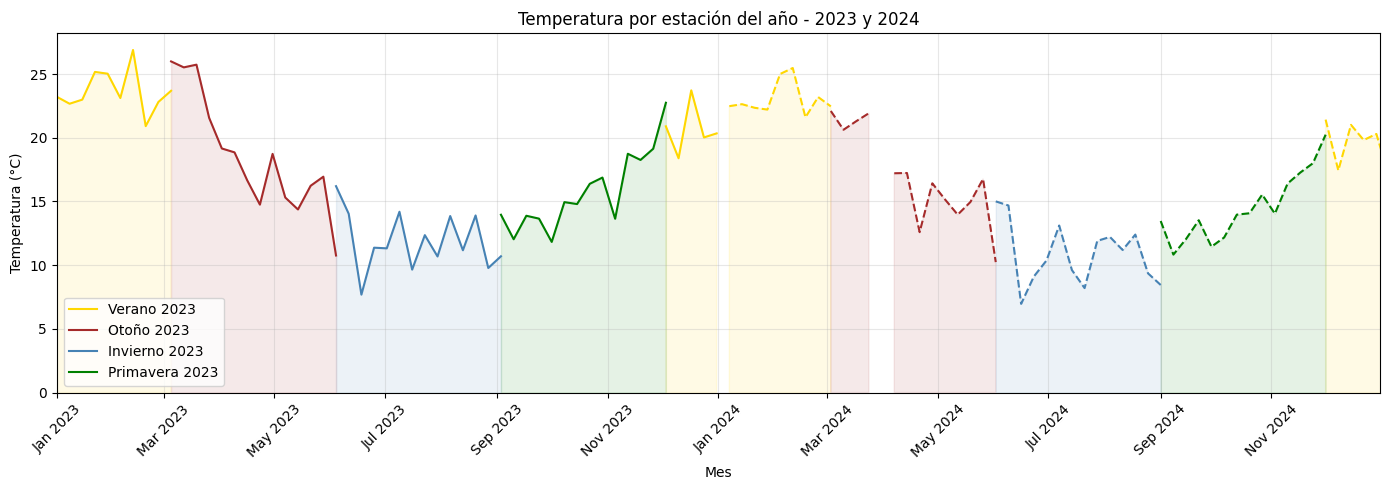

In [74]:
# Promedio diario de todas las estaciones
df_diario = df_concatenado.groupby('fecha')['TempAire'].mean().resample('D').mean()

df_2023_diario = df_diario['2023']
df_2024_diario = df_diario['2024']

# Calcular factor de corrección (diferencia promedio en meses que se superponen)
meses_comunes = df_2024_diario.index.month.unique()  # enero, febrero, marzo
mask_2023 = df_2023_diario.index.month.isin(meses_comunes)
mask_2024 = df_2024_diario.index.month.isin(meses_comunes)

factor = df_2024_diario[mask_2024].mean() - df_2023_diario[mask_2023].mean()
print(f"Factor de corrección: {factor:.2f}°C")

# Tomar abril-diciembre 2023 y aplicar el factor
df_2023_resto = df_2023_diario[df_2023_diario.index.month > 3].copy()
df_2024_estimado = df_2023_resto.copy()
df_2024_estimado.index = df_2024_estimado.index.map(lambda x: x.replace(year=2024))
df_2024_estimado = df_2024_estimado + factor

# Unir datos reales de 2024 con estimados
df_2024_completo = pd.concat([df_2024_diario, df_2024_estimado])

# Agregar columna de estación
def estacion(fecha):
    mes = fecha.month
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    else:
        return 'Primavera'

df_2024_completo = df_2024_completo.to_frame(name='TempAire')
df_2024_completo['estacion'] = df_2024_completo.index.map(estacion)

# Unir 2023 completo con 2024 completo (real + estimado)
df_2023_diario = df_diario['2023'].to_frame(name='TempAire')
df_2024_completo = pd.concat([df_2024_diario, df_2024_estimado]).to_frame(name='TempAire')

df_todo = pd.concat([df_2023_diario, df_2024_completo])
df_todo['estacion'] = df_todo.index.map(estacion)

# Graficar
fig, ax = plt.subplots(figsize=(14, 5))

for año, estilo in [('2023', '-'), ('2024', '--')]:
    df_año = df_todo[df_todo.index.year == int(año)]
    for est in ['Verano', 'Otoño', 'Invierno', 'Primavera']:
        df_est = df_año[df_año['estacion'] == est]['TempAire'].resample('W').mean()
        ax.plot(df_est.index, df_est.values, 
                color=colores[est], linewidth=1.5, 
                linestyle=estilo,
                label=f'{est} {año}' if año == '2023' else '_nolegend_')
        ax.fill_between(df_est.index, df_est.values, alpha=0.1, color=colores[est])

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-12-31'))
ax.set_title('Temperatura por estación del año - 2023 y 2024')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
ax.set_ylim(0, None)
plt.show()
